In [21]:

import cv2
import numpy as np
from ultralytics import YOLO


class ShapeDetector:
    def __init__(self, model_path="../workdir/ros2_ws/model/shape.pt", conf=0.5, imgsz=640):
        """
        基本图形检测器
        参数:
            model_path: 模型路径（需支持多类别检测）
            conf: 置信度阈值
            imgsz: 推理尺寸
        """
        self.model = YOLO(model_path)
        self.model.fuse()
        self.conf = conf
        self.imgsz = imgsz
        # 定义颜色类别映射
        self.cls_map = {
            0: ("circle", (255, 0, 0)),  # 蓝色
            1: ("square", (0, 255, 0)),  # 绿色
            2: ("triangle", (0, 0, 255)),  # 红色
        }
        # 创建名称到颜色的映射
        self.name_to_color = {name: color for _,
                              (name, color) in self.cls_map.items()}

    def detect(self, image):
        """
        参数:
            image: 输入BGR/BGRA图像
        返回:
            dict
        """
        # 通道转换处理
        if image.shape[2] == 4:
            image = cv2.cvtColor(image, cv2.COLOR_BGRA2BGR)

        # 执行检测并处理结果
        results = self.model.predict(
            image,
            task="segment",
            imgsz=self.imgsz,
            conf=self.conf,
            device="cuda" if next(
                self.model.model.parameters()).is_cuda else "cpu",
            verbose=False,
        )
        return self._process_detections(results)

    def _process_detections(self, results):
        """处理检测结果并分类存储"""
        detections = {"circle": None, "square": None, "triangle": None}
        for result in results:
            if result.masks is None:
                continue
            for mask, box in zip(result.masks.xy, result.boxes):
                if box.conf[0] < self.conf:  # 使用类中的conf阈值
                    continue
                conf = box.conf[0].item()  # 转换为Python浮点数
                cls_id = int(box.cls[0])
                polygon = mask.astype(np.int32)
                xyxy = box.xyxy[0].cpu().numpy()
                # if box.

                # 添加轮廓验证
                if polygon.size == 0 or len(polygon) < 3:
                    print(f"跳过无效轮廓: cls_id={cls_id}, 点数={len(polygon)}")
                    continue

                # 只处理预定义的颜色类别
                if cls_id in self.cls_map:
                    cls_name, _ = self.cls_map[cls_id]
                    # 选择置信度最高的结果
                    if (
                        detections[cls_name] is None
                        or conf > detections[cls_name]["conf"]
                    ):
                        detections[cls_name] = {
                            "xyxy": xyxy,
                            "conf": conf,
                            "polygon": polygon,  # 添加多边形点用于可视化
                        }
        if detections["circle"] is not None:
            print("circle detected")
        if detections["square"] is not None:
            print("square detected")
        if detections["triangle"] is not None:
            print("triangle detected")

        return detections

    def visualize(self, image, detections):
        """
        可视化检测结果
        参数:
            image: 原始输入图像
            detections: 检测结果字典

        返回:
            result_img: 带标记的结果图像
        """
        # 创建可写副本
        if image.shape[2] == 4:
            result_img = image.copy()
        else:
            result_img = cv2.cvtColor(image, cv2.COLOR_BGR2BGRA)

        # 遍历所有检测结果
        for cls_name, detection in detections.items():
            if detection is None:
                continue

            # 直接通过名称获取颜色
            if cls_name not in self.name_to_color:
                continue  # 跳过未定义类别的名称
            color = self.name_to_color[cls_name]
            bgr_color = color  # 直接使用定义的颜色元组

            # 创建带透明度的颜色
            color_with_alpha = (*bgr_color, 255)

            # 绘制边界框
            x1, y1, x2, y2 = detection["xyxy"].astype(int)
            cv2.rectangle(result_img, (x1, y1), (x2, y2), color_with_alpha, 3)

            # 绘制类别和置信度文本
            label = f"{cls_name}: {detection['conf']:.2f}"
            cv2.putText(
                result_img,
                label,
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                color_with_alpha,
                2,
            )

            # 绘制多边形轮廓（如果存在）
            if "polygon" in detection:
                cv2.polylines(
                    result_img, [detection["polygon"]
                                 ], True, color_with_alpha, 2
                )

        return result_img



In [22]:
frame = cv2.imread('../sub_test.jpg')

In [23]:
shape_detector = ShapeDetector()
detections = shape_detector.detect(frame)
result = shape_detector.visualize(frame, detections)

YOLO11n-seg summary (fused): 113 layers, 2,835,153 parameters, 0 gradients, 10.2 GFLOPs


In [24]:
from matplotlib import pyplot as plt
%matplotlib inline


def show_image(img):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

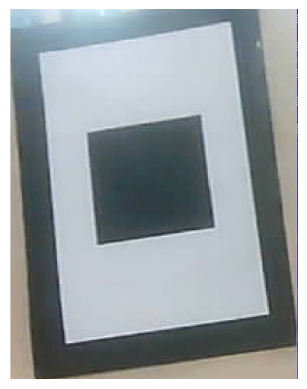

In [25]:
show_image(result)